In [1]:
# Cell 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Cell 2: Load Dataset

file_path = r"C:\Users\bts\OneDrive\Desktop\SaiKet Systems\dataset\Telco_Customer_Churn_Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Cell 3: Display First 5 Rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Cell 4: Dataset Shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [5]:
# Cell 5: Column Names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
# Cell 6: Data Types

print("Data Types:")
print(df.dtypes)

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [7]:
# Cell 7: Missing Values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
# Cell 8: Duplicate Records

print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [9]:
# Cell 9: Statistical Summary

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# Cell 10: Identify Numerical and Categorical Columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [11]:
# Cell 11: Data Cleaning

# Convert TotalCharges to numeric if the column exists
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

# Remove rows with missing TotalCharges
if "TotalCharges" in df.columns:
    df = df.dropna(subset=["TotalCharges"])

# Remove duplicate records
df = df.drop_duplicates()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [12]:
# Cell 12: Check Dataset After Cleaning

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate records:
0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        st

In [13]:
# Cell 13: Overall Churn Count

churn_count = df["Churn"].value_counts()

print("Customer Churn Count:")
print(churn_count)

Customer Churn Count:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [14]:
# Cell 14: Overall Churn Rate

churned_customers = (df["Churn"] == "Yes").sum()
not_churned_customers = (df["Churn"] == "No").sum()

overall_churn_rate = (
    churned_customers / len(df)
) * 100

print("Customers who churned:", churned_customers)
print("Customers who did not churn:", not_churned_customers)
print("Overall churn rate:", round(overall_churn_rate, 2), "%")

Customers who churned: 1869
Customers who did not churn: 5163
Overall churn rate: 26.58 %


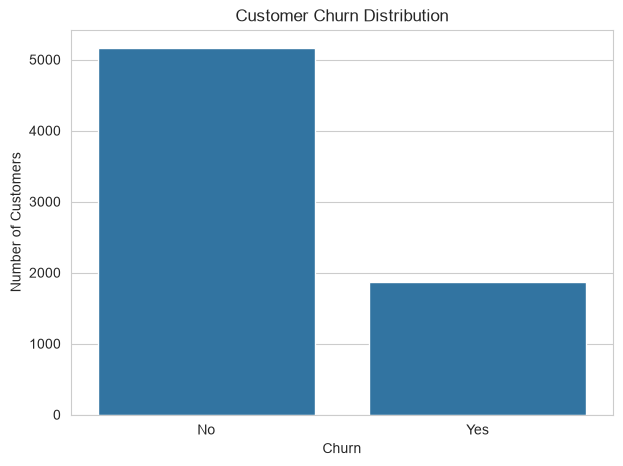

In [15]:
# Cell 15: Churn Distribution Visualization

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

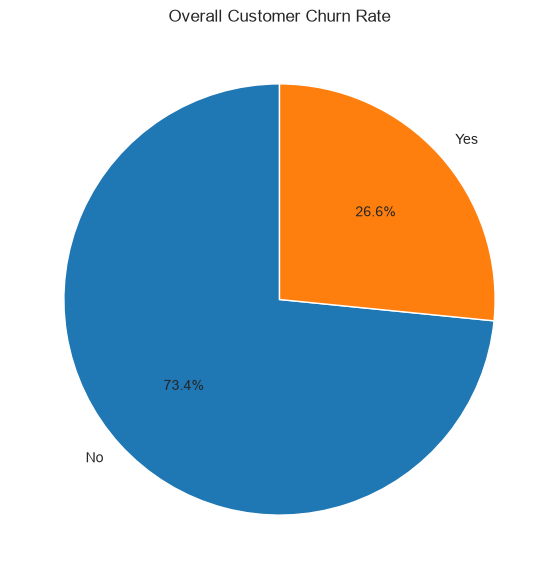

In [16]:
# Cell 16: Churn Pie Chart

plt.figure(figsize=(7, 7))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Customer Churn Rate")
plt.ylabel("")

plt.show()

In [17]:
# Cell 17: Gender Customer Count

gender_count = df["gender"].value_counts()

print("Customer Count by Gender:")
print(gender_count)

Customer Count by Gender:
gender
Male      3549
Female    3483
Name: count, dtype: int64


In [18]:
# Cell 18: Gender Churn Summary

gender_summary = df.groupby("gender").agg(
    Total_Customers=("Churn", "count"),
    Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
)

gender_summary["Churn_Rate"] = (
    gender_summary["Churned_Customers"] /
    gender_summary["Total_Customers"] * 100
)

print(gender_summary)

        Total_Customers  Churned_Customers  Churn_Rate
gender                                                
Female             3483                939   26.959518
Male               3549                930   26.204565


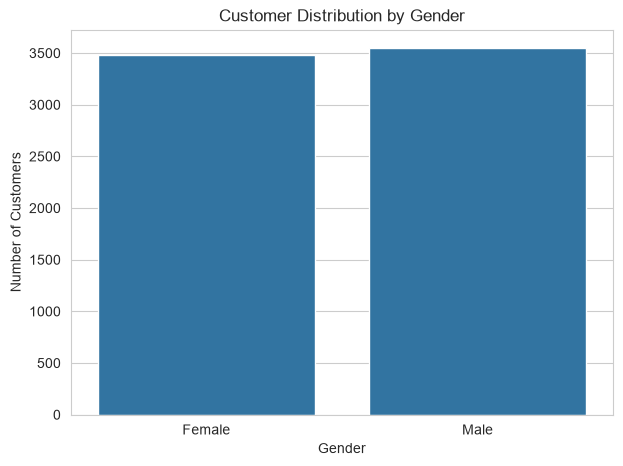

In [19]:
# Cell 19: Gender Distribution Visualization

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

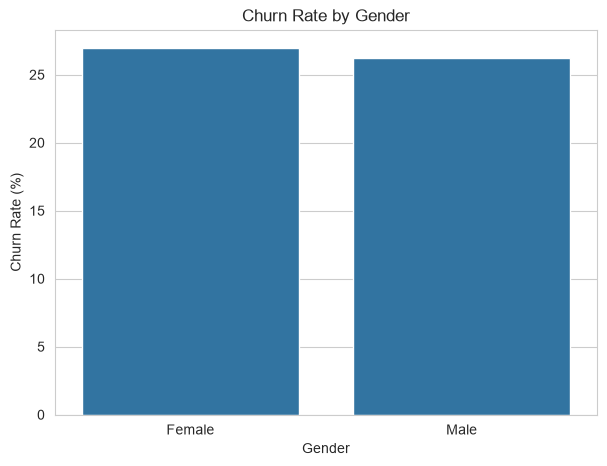

In [20]:
# Cell 20: Churn Rate by Gender

plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_summary.reset_index(),
    x="gender",
    y="Churn_Rate"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

In [21]:
# Cell 21: Partner Customer Count

partner_count = df["Partner"].value_counts()

print("Customer Count by Partner Status:")
print(partner_count)

Customer Count by Partner Status:
Partner
No     3639
Yes    3393
Name: count, dtype: int64


In [22]:
# Cell 22: Partner Churn Summary

partner_summary = df.groupby("Partner").agg(
    Total_Customers=("Churn", "count"),
    Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
)

partner_summary["Churn_Rate"] = (
    partner_summary["Churned_Customers"] /
    partner_summary["Total_Customers"] * 100
)

print(partner_summary)

         Total_Customers  Churned_Customers  Churn_Rate
Partner                                                
No                  3639               1200   32.976092
Yes                 3393                669   19.717065


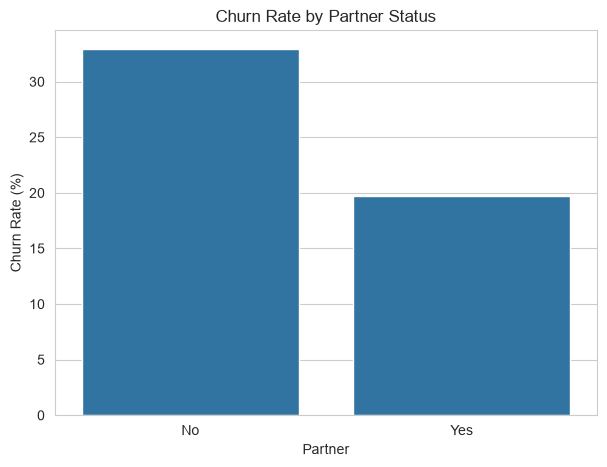

In [23]:
# Cell 23: Churn Rate by Partner

plt.figure(figsize=(7, 5))

sns.barplot(
    data=partner_summary.reset_index(),
    x="Partner",
    y="Churn_Rate"
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")

plt.show()

In [24]:
# Cell 24: Dependents Customer Count

dependent_count = df["Dependents"].value_counts()

print("Customer Count by Dependents:")
print(dependent_count)

Customer Count by Dependents:
Dependents
No     4933
Yes    2099
Name: count, dtype: int64


In [25]:
# Cell 25: Dependents Churn Summary

dependent_summary = df.groupby("Dependents").agg(
    Total_Customers=("Churn", "count"),
    Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
)

dependent_summary["Churn_Rate"] = (
    dependent_summary["Churned_Customers"] /
    dependent_summary["Total_Customers"] * 100
)

print(dependent_summary)

            Total_Customers  Churned_Customers  Churn_Rate
Dependents                                                
No                     4933               1543   31.279140
Yes                    2099                326   15.531205


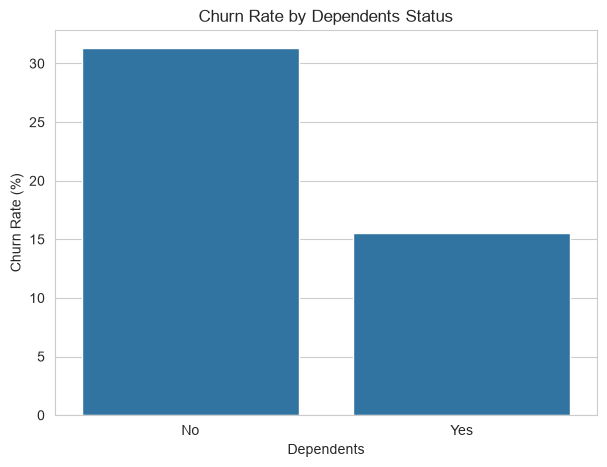

In [26]:
# Cell 26: Churn Rate by Dependents

plt.figure(figsize=(7, 5))

sns.barplot(
    data=dependent_summary.reset_index(),
    x="Dependents",
    y="Churn_Rate"
)

plt.title("Churn Rate by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")

plt.show()

In [27]:
# Cell 27: Tenure Descriptive Statistics

print("Tenure Statistics:")
print(df["tenure"].describe())

Tenure Statistics:
count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


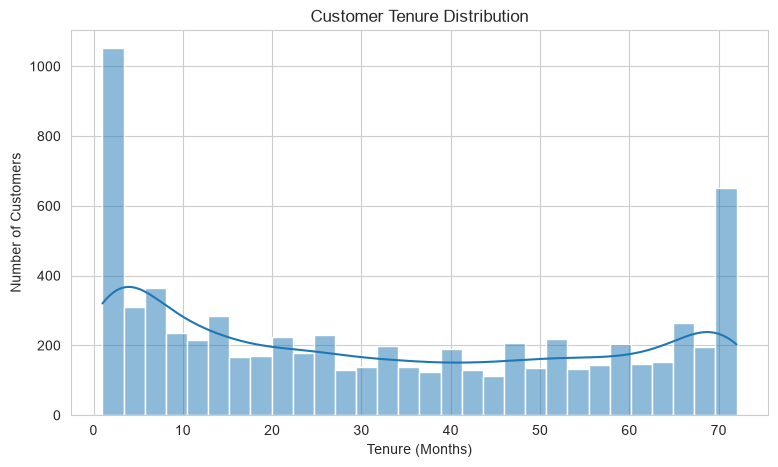

In [28]:
# Cell 28: Tenure Histogram

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

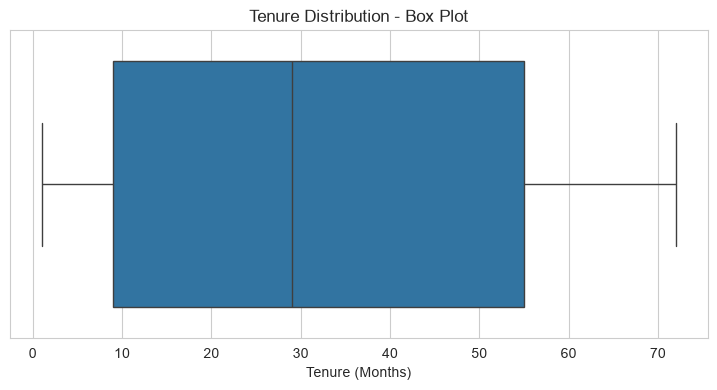

In [29]:
# Cell 29: Tenure Box Plot

plt.figure(figsize=(9, 4))

sns.boxplot(
    x=df["tenure"]
)

plt.title("Tenure Distribution - Box Plot")
plt.xlabel("Tenure (Months)")

plt.show()

In [30]:
# Cell 30: Create Tenure Groups

bins = [-1, 12, 24, 48, 60, np.inf]

labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-60 months",
    "61+ months"
]

df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels
)

print(df[["tenure", "Tenure_Group"]].head())

   tenure  Tenure_Group
0       1   0-12 months
1      34  25-48 months
2       2   0-12 months
3      45  25-48 months
4       2   0-12 months


In [31]:
# Cell 31: Tenure Group Churn Summary

tenure_summary = df.groupby(
    "Tenure_Group",
    observed=False
).agg(
    Total_Customers=("Churn", "count"),
    Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
)

tenure_summary["Churn_Rate"] = (
    tenure_summary["Churned_Customers"] /
    tenure_summary["Total_Customers"] * 100
)

print(tenure_summary)

              Total_Customers  Churned_Customers  Churn_Rate
Tenure_Group                                                
0-12 months              2175               1037   47.678161
13-24 months             1024                294   28.710938
25-48 months             1594                325   20.388959
49-60 months              832                120   14.423077
61+ months               1407                 93    6.609808


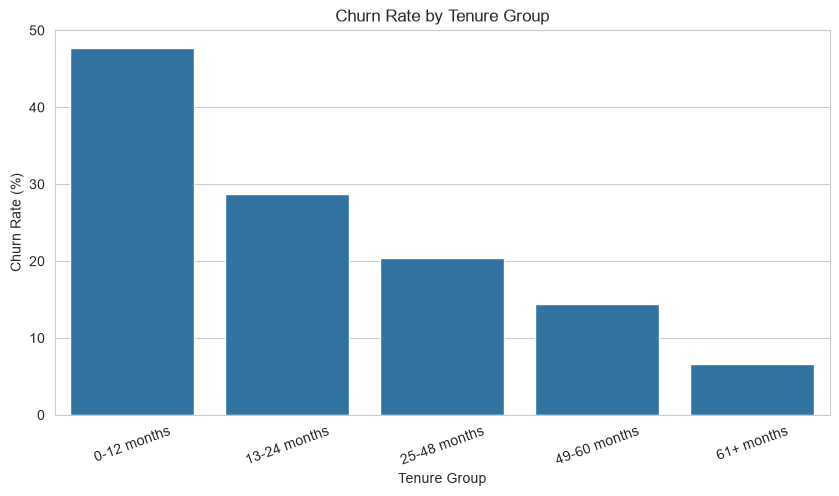

In [32]:
# Cell 32: Churn Rate by Tenure Group

plt.figure(figsize=(10, 5))

sns.barplot(
    data=tenure_summary.reset_index(),
    x="Tenure_Group",
    y="Churn_Rate"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.show()

In [33]:
# Cell 33: Contract Customer Count

contract_count = df["Contract"].value_counts()

print("Customer Count by Contract Type:")
print(contract_count)

Customer Count by Contract Type:
Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64


In [34]:
# Cell 34: Contract Churn Summary

contract_summary = df.groupby("Contract").agg(
    Total_Customers=("Churn", "count"),
    Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
)

contract_summary["Churn_Rate"] = (
    contract_summary["Churned_Customers"] /
    contract_summary["Total_Customers"] * 100
)

print(contract_summary)

                Total_Customers  Churned_Customers  Churn_Rate
Contract                                                      
Month-to-month             3875               1655   42.709677
One year                   1472                166   11.277174
Two year                   1685                 48    2.848665


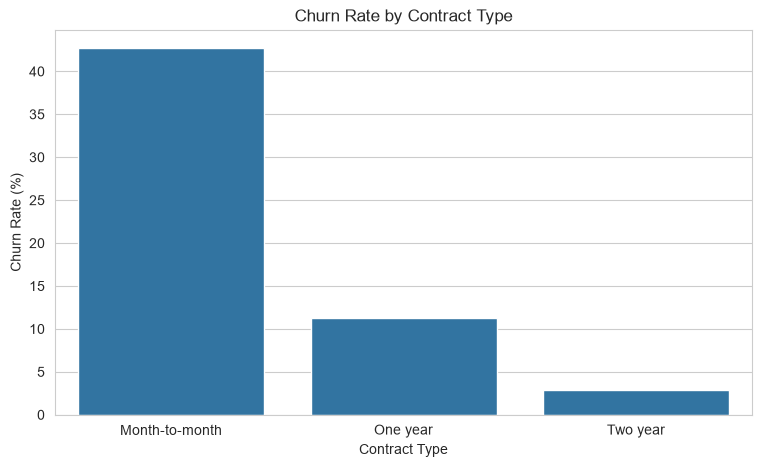

In [35]:
# Cell 35: Churn Rate by Contract Type

plt.figure(figsize=(9, 5))

sns.barplot(
    data=contract_summary.reset_index(),
    x="Contract",
    y="Churn_Rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

In [36]:
# Cell 36: Payment Method Customer Count

payment_count = df["PaymentMethod"].value_counts()

print("Customer Count by Payment Method:")
print(payment_count)

Customer Count by Payment Method:
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64


In [37]:
# Cell 37: Payment Method Churn Summary

payment_summary = df.groupby("PaymentMethod").agg(
    Total_Customers=("Churn", "count"),
    Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
)

payment_summary["Churn_Rate"] = (
    payment_summary["Churned_Customers"] /
    payment_summary["Total_Customers"] * 100
)

print(payment_summary)

                           Total_Customers  Churned_Customers  Churn_Rate
PaymentMethod                                                            
Bank transfer (automatic)             1542                258   16.731518
Credit card (automatic)               1521                232   15.253123
Electronic check                      2365               1071   45.285412
Mailed check                          1604                308   19.201995


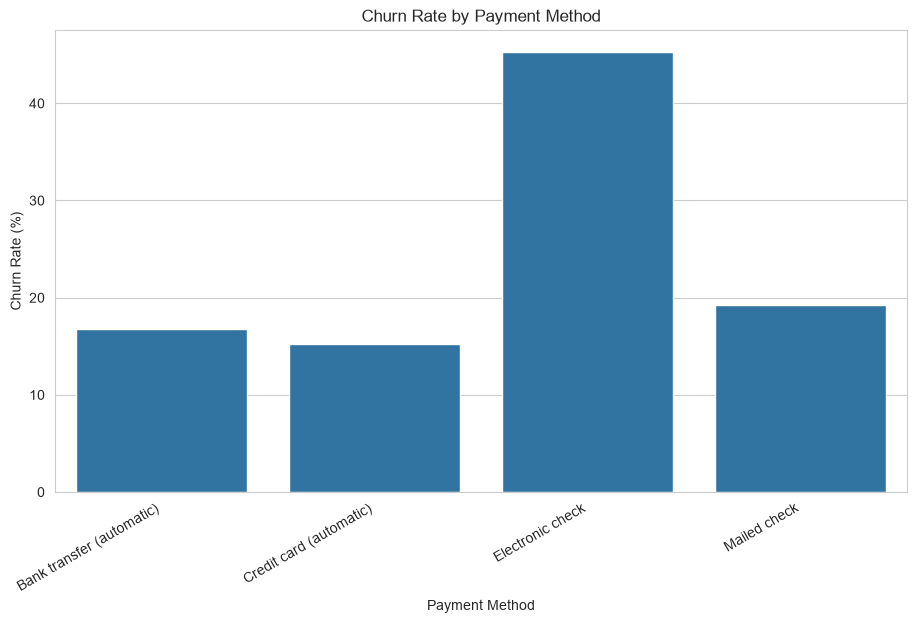

In [38]:
# Cell 38: Churn Rate by Payment Method

plt.figure(figsize=(11, 6))

sns.barplot(
    data=payment_summary.reset_index(),
    x="PaymentMethod",
    y="Churn_Rate"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.show()

In [39]:
# Cell 39: Find Highest Churn Groups

highest_gender = gender_summary["Churn_Rate"].idxmax()
highest_partner = partner_summary["Churn_Rate"].idxmax()
highest_dependents = dependent_summary["Churn_Rate"].idxmax()
highest_tenure = tenure_summary["Churn_Rate"].idxmax()
highest_contract = contract_summary["Churn_Rate"].idxmax()
highest_payment = payment_summary["Churn_Rate"].idxmax()

print("Highest churn gender group:", highest_gender)
print("Highest churn partner group:", highest_partner)
print("Highest churn dependents group:", highest_dependents)
print("Highest churn tenure group:", highest_tenure)
print("Highest churn contract group:", highest_contract)
print("Highest churn payment method:", highest_payment)

Highest churn gender group: Female
Highest churn partner group: No
Highest churn dependents group: No
Highest churn tenure group: 0-12 months
Highest churn contract group: Month-to-month
Highest churn payment method: Electronic check


In [40]:
# Cell 40: Display Important Churn Rates

print("========== KEY CHURN RATES ==========")

print("\nOverall Churn Rate:")
print(round(overall_churn_rate, 2), "%")

print("\nGender:")
print(gender_summary)

print("\nPartner:")
print(partner_summary)

print("\nDependents:")
print(dependent_summary)

print("\nTenure:")
print(tenure_summary)

print("\nContract:")
print(contract_summary)

print("\nPayment Method:")
print(payment_summary)

========== KEY CHURN RATES ==========

Overall Churn Rate:
26.58 %

Gender:
        Total_Customers  Churned_Customers  Churn_Rate
gender                                                
Female             3483                939   26.959518
Male               3549                930   26.204565

Partner:
         Total_Customers  Churned_Customers  Churn_Rate
Partner                                                
No                  3639               1200   32.976092
Yes                 3393                669   19.717065

Dependents:
            Total_Customers  Churned_Customers  Churn_Rate
Dependents                                                
No                     4933               1543   31.279140
Yes                    2099                326   15.531205

Tenure:
              Total_Customers  Churned_Customers  Churn_Rate
Tenure_Group                                                
0-12 months              2175               1037   47.678161
13-24 months             1024

In [41]:
# Cell 41: Business Recommendations

print("========== BUSINESS RECOMMENDATIONS ==========\n")

print("1. Focus retention efforts on customer groups with higher observed churn rates.")

print("2. Pay special attention to contract types with higher churn, especially if month-to-month customers show significantly higher churn.")

print("3. If low-tenure customers have higher churn, improve onboarding and early customer engagement.")

print("4. Investigate payment methods with unusually high churn rates.")

print("5. Develop targeted retention offers instead of using the same strategy for all customers.")

print("6. Future analysis should combine multiple variables such as tenure, contract type, and payment method to identify high-risk customer segments.")

========== BUSINESS RECOMMENDATIONS ==========

1. Focus retention efforts on customer groups with higher observed churn rates.
2. Pay special attention to contract types with higher churn, especially if month-to-month customers show significantly higher churn.
3. If low-tenure customers have higher churn, improve onboarding and early customer engagement.
4. Investigate payment methods with unusually high churn rates.
5. Develop targeted retention offers instead of using the same strategy for all customers.
6. Future analysis should combine multiple variables such as tenure, contract type, and payment method to identify high-risk customer segments.


In [42]:
# Cell 42: Final Dataset Summary

print("========== FINAL EDA SUMMARY ==========")

print("Total Customers:", len(df))
print("Churned Customers:", churned_customers)
print("Customers Not Churned:", not_churned_customers)
print("Overall Churn Rate:", round(overall_churn_rate, 2), "%")

print("\nHighest Churn Contract:")
print(
    highest_contract,
    "-",
    round(contract_summary.loc[highest_contract, "Churn_Rate"], 2),
    "%"
)

print("\nHighest Churn Tenure Group:")
print(
    highest_tenure,
    "-",
    round(tenure_summary.loc[highest_tenure, "Churn_Rate"], 2),
    "%"
)

print("\nHighest Churn Payment Method:")
print(
    highest_payment,
    "-",
    round(payment_summary.loc[highest_payment, "Churn_Rate"], 2),
    "%"
)

========== FINAL EDA SUMMARY ==========
Total Customers: 7032
Churned Customers: 1869
Customers Not Churned: 5163
Overall Churn Rate: 26.58 %

Highest Churn Contract:
Month-to-month - 42.71 %

Highest Churn Tenure Group:
0-12 months - 47.68 %

Highest Churn Payment Method:
Electronic check - 45.29 %
